# DIMITRIS NTAOULTZIS 5311

# Hand Sign Recognition Challenge

## 1. Dataset Description

The dataset used is the **Sign Language MNIST**, a variation of the classic 
MNIST dataset for recognizing **American Sign Language (ASL)** hand gestures.

The dataset includes:
- **27,455 training images**
- **7,172 test images** (not used in training)
- **Grayscale 28×28 pixel** images
- **24 classes** (letters A-Y, excluding J and Z as they require motion)

Each image is represented as a vector of 784 pixel values ranging from 0 to 255.
The dataset was created from 1,704 original color images, which were expanded 
through **data augmentation** techniques (rotation, brightness adjustment, 
pixelation, etc.) to reach 27,455 samples.

The class distribution is relatively balanced, with the most frequent class 
having 1,294 samples (label 17 = R) and the least frequent having 957 samples 
(label 4 = E), making class imbalance a non-critical issue for this dataset.

# To run all models uncomment the line **X = X / 255.0**  in the 4th code cell

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics.pairwise import cosine_similarity


## 2. Data Preprocessing

The following preprocessing steps were applied to the dataset:

### 2.1 Data Loading
The dataset was loaded from the CSV file using **pandas**. Each row contains 
a label and 784 pixel values representing a 28×28 grayscale image.

### 2.2 Normalization
Pixel values were normalized by dividing by 255, scaling them from the 
range [0, 255] to [0, 1]. This step is crucial for:
- Ensuring all features are on the same scale
- Improving training speed and stability
- Enhancing the performance of distance-based algorithms (kNN, SVM)

Normalization was incorporated into a **scikit-learn Pipeline** alongside 
each model, ensuring it is applied automatically and consistently during 
both training and prediction.

### 2.3 Train/Validation Split
The 27,455 training samples were split into:
- **Training set: 80%** → 21,964 samples
- **Validation set: 20%** → 5,491 samples

The split was performed using **stratified sampling** (`stratify=y`) to ensure 
proportional class representation in both sets.

In [2]:

df = pd.read_csv('sign_mnist_train.csv')

X = df.drop('label', axis=1)
y = df['label']

print(df.shape)
print(df.head())


(27455, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  pixel783  pixel784  
0       206      

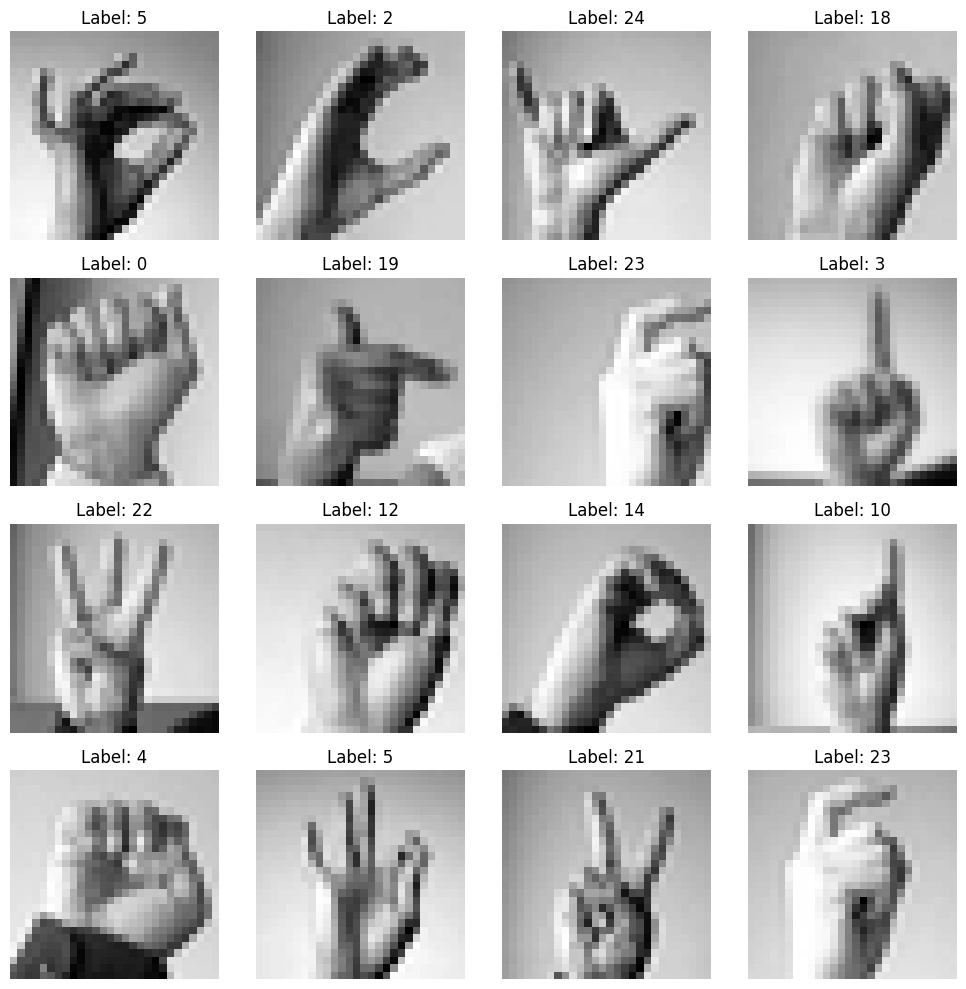

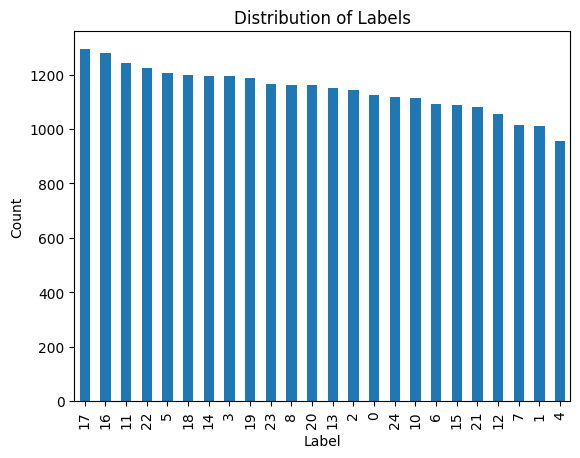

In [ ]:

fig, axes = plt.subplots(4, 4, figsize=(10, 10)) # 4x4 grid για 16 εικόνες
for i in range(4):
    for j in range(4):
        #random index
        idx = np.random.randint(0, len(X))
        image = X.iloc[idx].values.reshape(28, 28)
        # .values → μετατροπή από pandas σε numpy array
        # .reshape(28, 28) → από (784,) σε (28, 28)
        axes[i, j].imshow(image, cmap='gray')
        axes[i, j].set_title(f"Label: {y.iloc[idx]}")
        axes[i, j].axis('off') #Hide axes
plt.tight_layout() #Για να μην επικαλύπτονται οι εικόνες
plt.show()

y.value_counts().plot(kind='bar') #Πόσες φορές εμφανίζεται κάθε label
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


In [ ]:
#print(y.value_counts())

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y) #Διαχωρισμός σε train και test set
#X_train_small = X_train[:500] #Μικρότερο training set για ταχύτητα
#y_train_small = y_train[:500]

#X = X / 255.0 #Κανονικοποίηση των pixel values (0-255) σε 0-1

#print(X_train.shape)
#print(X_val.shape)
#print(y_train.shape)
#print(y_val.shape)


## 3. Classification Models

All models were implemented using **scikit-learn 1.8.0**. For each model, 
multiple hyperparameter combinations were evaluated on the validation set.

### 3.1 k-Nearest Neighbors (kNN)
The kNN algorithm classifies a sample based on the majority vote of its 
k nearest neighbors in the training set.

| k | Metric | Accuracy | F1 Score |
|---|--------|----------|----------|
| 1 | Euclidean | 0.9998 | 0.9998 |
| 1 | Manhattan | 0.9965 | 0.9965 |
| 1 | Cosine | 1.0000 | 1.0000 |
| 3 | Euclidean | 0.9982 | 0.9982 |
| 5 | Euclidean | 0.9947 | 0.9947 |
| 7 | Euclidean | 0.9924 | 0.9924 |
| 11 | Euclidean | 0.9869 | 0.9869 |

**Best configuration:** k=1, metric=Cosine (Accuracy: 1.0000)

### 3.2 Support Vector Machines (SVM)
SVMs find the optimal hyperplane that maximizes the margin between classes.

| Kernel | C | Gamma | Accuracy | F1 Score |
|--------|---|-------|----------|----------|
| Linear | 0.1 | - | 1.0000 | 1.0000 |
| Linear | 1 | - | 1.0000 | 1.0000 |
| Linear | 10 | - | 1.0000 | 1.0000 |
| RBF | 1 | 0.1 | 0.9995 | 0.9995 |
| RBF | 10 | 0.01 | 1.0000 | 1.0000 |
| Precomputed (Cosine) | 10 | - | 0.9918 | 0.9918 |

**Best configuration:** Linear kernel, C=1 (Accuracy: 1.0000)

### 3.3 Decision Trees
Decision Trees recursively split the data based on feature thresholds.

| Max Depth | Min Samples Leaf | Criterion | Accuracy | F1 Score |
|-----------|-----------------|-----------|----------|----------|
| 5 | 1 | Gini | 0.2941 | 0.2666 |
| 10 | 1 | Entropy | 0.7461 | 0.7470 |
| 20 | 1 | Entropy | 0.8931 | 0.8931 |
| 20 | 5 | Entropy | 0.8483 | 0.8482 |

**Best configuration:** max_depth=20, min_samples_leaf=1, criterion=Entropy 
(Accuracy: 0.8931)

### 3.4 Ensemble Methods

#### Random Forest
Random Forest combines multiple Decision Trees trained on random subsets 
of the data, using majority voting for the final prediction.

| N Estimators | Max Depth | Accuracy | F1 Score |
|-------------|-----------|----------|----------|
| 10 | 10 | 0.9115 | 0.9115 |                           
| 50 | 20 | 0.9954 | 0.9954 |
| 100 | 20 | 0.9953 | 0.9953 |
| 200 | None | 0.9965 | 0.9965 |

**Best configuration:** n_estimators=200, max_depth=None (Accuracy: 0.9965)

#### AdaBoost
AdaBoost sequentially trains weak classifiers, focusing on previously 
misclassified samples.

| N Estimators | Learning Rate | Accuracy | F1 Score |
|-------------|---------------|----------|----------|
| 50 | 0.1 | 0.1120 |  0.0490 |                                                 
| 100 | 1.0 | 0.2673 | 0.2598 |                     
| 200 | 1.0 | 0.3100 | 0.2989 |

**Best configuration:** n_estimators=200, learning_rate=1.0 (Accuracy: 0.3100)

**Note:** AdaBoost performed poorly on this dataset due to its reliance on 
simple decision stumps (max_depth=1), which are too weak for a complex 
24-class image classification problem with 784 features.

### 3.5 Feedforward Neural Networks (FNN)
FNNs were implemented using scikit-learn's MLPClassifier with ReLU activation.

| Hidden Layers | Architecture | Accuracy | F1 Score |
|--------------|-------------|----------|----------|
| 1 | (128,) | 1.0000 | 1.0000 |
| 2 | (128, 128) | 0.7108 | 0.6967 |                   
| 3 | (128, 128, 128) | 1.0000 | 1.0000 |

**Best configuration:** 1 hidden layer (128,) (Accuracy: 1.0000)

### 3.6 Convolutional Neural Networks (CNN)
CNNs were implemented using **PyTorch**. They apply convolutional filters 
to capture spatial patterns in images.

| Conv Layers | Kernels | Kernel Size | Accuracy | F1 Score |
|------------|---------|-------------|----------|----------|
| 1 | 16 | 3 | 1.0000 | 1.0000 |
| 1 | 32 | 5 | 1.0000 | 1.0000 |
| 2 | 16 | 3 | 0.9996 | 0.9996 |
| 2 | 32 | 3 | 0.9998 | 0.9998 |

**Best configuration:** 1 conv layer, 32 kernels, kernel_size=5 (Accuracy: 1.0000)

**Note:** CNN was implemented for evaluation purposes only and was not 
selected as the final model, as scikit-learn does not support CNN architectures.

In [ ]:
#KNN
for k in [1, 3, 5, 7, 11]:
    for metric in ['euclidean', 'manhattan', 'cosine']:
       knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
       knn.fit(X_train, y_train)
       y_pred = knn.predict(X_val)
       acc = accuracy_score(y_val, y_pred)
       f1 = f1_score(y_val, y_pred, average='weighted')
       print(f"k={k}, metric={metric} => Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

k=1, metric=euclidean => Accuracy: 0.9998, F1 Score: 0.9998
k=1, metric=manhattan => Accuracy: 0.9965, F1 Score: 0.9965
k=1, metric=cosine => Accuracy: 1.0000, F1 Score: 1.0000
k=3, metric=euclidean => Accuracy: 0.9982, F1 Score: 0.9982
k=3, metric=manhattan => Accuracy: 0.9918, F1 Score: 0.9918
k=3, metric=cosine => Accuracy: 1.0000, F1 Score: 1.0000
k=5, metric=euclidean => Accuracy: 0.9947, F1 Score: 0.9947
k=5, metric=manhattan => Accuracy: 0.9849, F1 Score: 0.9849
k=5, metric=cosine => Accuracy: 1.0000, F1 Score: 1.0000
k=7, metric=euclidean => Accuracy: 0.9924, F1 Score: 0.9924
k=7, metric=manhattan => Accuracy: 0.9771, F1 Score: 0.9771
k=7, metric=cosine => Accuracy: 1.0000, F1 Score: 1.0000
k=11, metric=euclidean => Accuracy: 0.9869, F1 Score: 0.9869
k=11, metric=manhattan => Accuracy: 0.9638, F1 Score: 0.9638
k=11, metric=cosine => Accuracy: 1.0000, F1 Score: 1.0000


In [ ]:
#SVM
for kernel in ['precomputed', 'rbf', 'linear']:
    for C in [0.1, 1, 10]:
        if kernel == 'rbf':
            for gamma in [0.001, 0.01, 0.1]:                      #scale, auto
                svm = SVC(kernel=kernel, C=C, gamma=gamma)
                svm.fit(X_train, y_train)
                y_pred = svm.predict(X_val)
                acc = accuracy_score(y_val, y_pred)
                f1 = f1_score(y_val, y_pred, average='weighted')
                print(f"Kernel={kernel}, C={C}, gamma={gamma} => Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")
        elif kernel == 'precomputed':
            K_train = cosine_similarity(X_train, X_train)
            K_val = cosine_similarity(X_val, X_train)
            svm = SVC(kernel=kernel, C=C)
            svm.fit(K_train, y_train)
            y_pred = svm.predict(K_val)
            acc = accuracy_score(y_val, y_pred)
            f1 = f1_score(y_val, y_pred, average='weighted')
            print(f"Kernel={kernel}, C={C} => Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")
        else:
            svm = SVC(kernel=kernel, C=C)
            svm.fit(X_train, y_train)
            y_pred = svm.predict(X_val)
            acc = accuracy_score(y_val, y_pred)
            f1 = f1_score(y_val, y_pred, average='weighted')
            print(f"Kernel={kernel}, C={C} => Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")        

Kernel=precomputed, C=0.1 => Accuracy: 0.4138, F1 Score: 0.3742
Kernel=precomputed, C=1 => Accuracy: 0.8299, F1 Score: 0.8310
Kernel=precomputed, C=10 => Accuracy: 0.9918, F1 Score: 0.9918
Kernel=rbf, C=0.1, gamma=0.001 => Accuracy: 0.3202, F1 Score: 0.2712
Kernel=rbf, C=0.1, gamma=0.01 => Accuracy: 0.7567, F1 Score: 0.7556
Kernel=rbf, C=0.1, gamma=0.1 => Accuracy: 0.9709, F1 Score: 0.9708
Kernel=rbf, C=1, gamma=0.001 => Accuracy: 0.7609, F1 Score: 0.7601
Kernel=rbf, C=1, gamma=0.01 => Accuracy: 0.9882, F1 Score: 0.9882
Kernel=rbf, C=1, gamma=0.1 => Accuracy: 0.9995, F1 Score: 0.9995
Kernel=rbf, C=10, gamma=0.001 => Accuracy: 0.9798, F1 Score: 0.9799
Kernel=rbf, C=10, gamma=0.01 => Accuracy: 1.0000, F1 Score: 1.0000
Kernel=rbf, C=10, gamma=0.1 => Accuracy: 0.9993, F1 Score: 0.9993
Kernel=linear, C=0.1 => Accuracy: 1.0000, F1 Score: 1.0000
Kernel=linear, C=1 => Accuracy: 1.0000, F1 Score: 1.0000
Kernel=linear, C=10 => Accuracy: 1.0000, F1 Score: 1.0000


In [ ]:
#Decision Tree
for max_depth in [5, 10, 20,]:
    for min_samples_leaf in [1, 5, 10]:
        for criterion in ['gini', 'entropy']:
            dtc = DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, criterion=criterion)
            dtc.fit(X_train, y_train)
            y_pred = dtc.predict(X_val)
            acc = accuracy_score(y_val, y_pred)
            f1 = f1_score(y_val, y_pred, average='weighted')
            print(f"max_depth={max_depth}, min_samples_leaf={min_samples_leaf}, criterion={criterion} => Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

max_depth=5, min_samples_leaf=1, criterion=gini => Accuracy: 0.2941, F1 Score: 0.2666
max_depth=5, min_samples_leaf=1, criterion=entropy => Accuracy: 0.2925, F1 Score: 0.2795
max_depth=5, min_samples_leaf=5, criterion=gini => Accuracy: 0.2941, F1 Score: 0.2666
max_depth=5, min_samples_leaf=5, criterion=entropy => Accuracy: 0.2925, F1 Score: 0.2795
max_depth=5, min_samples_leaf=10, criterion=gini => Accuracy: 0.2941, F1 Score: 0.2666
max_depth=5, min_samples_leaf=10, criterion=entropy => Accuracy: 0.2925, F1 Score: 0.2795
max_depth=10, min_samples_leaf=1, criterion=gini => Accuracy: 0.6021, F1 Score: 0.6102
max_depth=10, min_samples_leaf=1, criterion=entropy => Accuracy: 0.7461, F1 Score: 0.7470
max_depth=10, min_samples_leaf=5, criterion=gini => Accuracy: 0.5959, F1 Score: 0.6040
max_depth=10, min_samples_leaf=5, criterion=entropy => Accuracy: 0.7378, F1 Score: 0.7386
max_depth=10, min_samples_leaf=10, criterion=gini => Accuracy: 0.5897, F1 Score: 0.5975
max_depth=10, min_samples_leaf=

Παρατηρήσεις:

max_depth=5: Πολύ χαμηλή απόδοση (~0.29)

max_depth=10: Μεσαία απόδοση (0.59-0.74)

max_depth=20: Καλύτερη απόδοση (0.78-0.90)

Entropy vs Gini: Το entropy είναι σταθερά καλύτερο από το gini σχεδόν σε όλες τις περιπτώσεις

min_samples_leaf: Το 1 δίνει γενικά καλύτερα αποτελέσματα

Συμπέρασμα για Decision Tree:

Καλύτερος συνδυασμός: max_depth=20, min_samples_leaf=1, criterion=entropy με 0.8931
Γενικά το Decision Tree υστερεί σημαντικά έναντι kNN και SVM

In [ ]:
# Ensemble Methods (Random Forest)
for n_estimators in [10, 50, 100, 200]:
    for max_depth in [10, 20, None]:
        rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='weighted')
        print(f"Random Forest - n_estimators={n_estimators}, max_depth={max_depth} => Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

Random Forest - n_estimators=10, max_depth=10 => Accuracy: 0.9115, F1 Score: 0.9115
Random Forest - n_estimators=10, max_depth=20 => Accuracy: 0.9811, F1 Score: 0.9810
Random Forest - n_estimators=10, max_depth=None => Accuracy: 0.9811, F1 Score: 0.9810
Random Forest - n_estimators=50, max_depth=10 => Accuracy: 0.9649, F1 Score: 0.9649
Random Forest - n_estimators=50, max_depth=20 => Accuracy: 0.9954, F1 Score: 0.9954
Random Forest - n_estimators=50, max_depth=None => Accuracy: 0.9942, F1 Score: 0.9942
Random Forest - n_estimators=100, max_depth=10 => Accuracy: 0.9732, F1 Score: 0.9734
Random Forest - n_estimators=100, max_depth=20 => Accuracy: 0.9953, F1 Score: 0.9953
Random Forest - n_estimators=100, max_depth=None => Accuracy: 0.9965, F1 Score: 0.9965
Random Forest - n_estimators=200, max_depth=10 => Accuracy: 0.9785, F1 Score: 0.9785
Random Forest - n_estimators=200, max_depth=20 => Accuracy: 0.9965, F1 Score: 0.9965
Random Forest - n_estimators=200, max_depth=None => Accuracy: 0.9

Παρατηρήσεις:

Όσο αυξάνει το n_estimators: Η απόδοση βελτιώνεται σταδιακά — περισσότερα δέντρα = καλύτερη πρόβλεψη

Όσο αυξάνει το max_depth: Επίσης βελτιώνεται — τα βαθύτερα δέντρα μαθαίνουν περισσότερα patterns

Καλύτερος συνδυασμός: n_estimators=200, max_depth=None με 0.9965

Σύγκριση με Decision Tree:

Καλύτερο Decision Tree: 0.8931

Καλύτερο Random Forest: 0.9965

In [ ]:
#Ensemble (AdaBoost)
for n_estimators in [10, 50, 100, 200]:
    for learning_rate in [0.01, 0.1, 1]:
        adb = AdaBoostClassifier(n_estimators=n_estimators, learning_rate=learning_rate)
        adb.fit(X_train, y_train)
        y_pred = adb.predict(X_val)
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='weighted')
        print(f"AdaBoost - n_estimators={n_estimators}, learning_rate={learning_rate} => Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

AdaBoost - n_estimators=10, learning_rate=0.01 => Accuracy: 0.0814, F1 Score: 0.0202
AdaBoost - n_estimators=10, learning_rate=0.1 => Accuracy: 0.0814, F1 Score: 0.0202
AdaBoost - n_estimators=10, learning_rate=1 => Accuracy: 0.0661, F1 Score: 0.0113
AdaBoost - n_estimators=50, learning_rate=0.01 => Accuracy: 0.0814, F1 Score: 0.0202
AdaBoost - n_estimators=50, learning_rate=0.1 => Accuracy: 0.1120, F1 Score: 0.0490
AdaBoost - n_estimators=50, learning_rate=1 => Accuracy: 0.1894, F1 Score: 0.1543
AdaBoost - n_estimators=100, learning_rate=0.01 => Accuracy: 0.0838, F1 Score: 0.0236
AdaBoost - n_estimators=100, learning_rate=0.1 => Accuracy: 0.1377, F1 Score: 0.0734
AdaBoost - n_estimators=100, learning_rate=1 => Accuracy: 0.2673, F1 Score: 0.2598
AdaBoost - n_estimators=200, learning_rate=0.01 => Accuracy: 0.1076, F1 Score: 0.0392
AdaBoost - n_estimators=200, learning_rate=0.1 => Accuracy: 0.1854, F1 Score: 0.1260
AdaBoost - n_estimators=200, learning_rate=1 => Accuracy: 0.3100, F1 Scor

Το AdaBoost αποδίδει άσχημα λόγο του max_depth = 1 που χρησιμοποιεί από προεπιλογή

In [ ]:
#FNN
for hidden_layer_sizes in [(128,), (128, 128), (128, 128, 128)]:
    mlp = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation='relu')
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    print(f"MLP - hidden_layer_sizes={hidden_layer_sizes} => Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

MLP - hidden_layer_sizes=(128,) => Accuracy: 1.0000, F1 Score: 1.0000
MLP - hidden_layer_sizes=(128, 128) => Accuracy: 0.7108, F1 Score: 0.6967
MLP - hidden_layer_sizes=(128, 128, 128) => Accuracy: 1.0000, F1 Score: 1.0000


In [ ]:
# Μετατροπή των δεδομένων σε PyTorch tensors
# Το CNN περιμένει μορφή (batch, channels, height, width)
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).reshape(-1, 1, 28, 28)
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).reshape(-1, 1, 28, 28)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

# DataLoader - τροφοδοτεί τα δεδομένα σε batches
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

Μετατρέπουμε τα pandas DataFrames σε PyTorch tensors
Κάνουμε reshape σε (samples, 1, 28, 28) — το 1 είναι ο αριθμός των καναλιών (grayscale = 1 κανάλι)
Φτιάχνουμε DataLoader που χωρίζει τα δεδομένα σε batches των 64

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_conv_layers, num_kernels, kernel_size):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, num_kernels, kernel_size=kernel_size, padding=1)
        self.conv2 = nn.Conv2d(num_kernels, num_kernels*2, kernel_size=kernel_size, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.num_conv_layers = num_conv_layers
        
        # Αυτόματος υπολογισμός fc_input_size
        dummy = torch.zeros(1, 1, 28, 28)
        dummy = self.relu(self.conv1(dummy))
        dummy = self.pool(dummy)
        if num_conv_layers == 2:
            dummy = self.relu(self.conv2(dummy))
            dummy = self.pool(dummy)
        fc_input_size = dummy.view(1, -1).shape[1]
            
        self.fc = nn.Linear(fc_input_size, 25)
    
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        if self.num_conv_layers == 2:
            x = self.relu(self.conv2(x))
            x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

Φτιάχνουμε μια κλάση CNN που κληρονομεί από nn.Module

Conv2d: Εφαρμόζει φίλτρα στην εικόνα

MaxPool2d: Μειώνει τις διαστάσεις στο μισό (28→14→7)

ReLU: Συνάρτηση ενεργοποίησης

Linear: Το τελικό fully connected layer με 24 εξόδους (μία για κάθε κλάση)

forward: Περιγράφει πώς "ρέουν" τα δεδομένα μέσα από το δίκτυο

In [ ]:
def train_cnn(model, train_loader, epochs=10):
    # Ορισμός loss function και optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            # Μηδένισε τα gradients
            optimizer.zero_grad()
            
            # Forward pass - πέρασε τα δεδομένα μέσα από το δίκτυο
            outputs = model(images)
            
            # Υπολόγισε το loss
            loss = criterion(outputs, labels)
            
            # Backward pass - υπολόγισε τα gradients
            loss.backward()
            
            # Ενημέρωσε τα weights
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

CrossEntropyLoss: Η συνάρτηση λάθους για classification

Adam optimizer: Αλγόριθμος που ενημερώνει τα weights

Forward pass: Τα δεδομένα περνάνε μέσα από το δίκτυο

Backward pass: Υπολογίζει πώς να βελτιώσει τα weights

optimizer.step(): Ενημερώνει τα weights με βάση τα gradients

In [ ]:
for num_conv_layers in [1, 2]:
    for num_kernels in [16, 32]:
        for kernel_size in [3, 5]:
            # Δημιούργησε το μοντέλο
            model = CNN(num_conv_layers, num_kernels, kernel_size)
            
            # Εκπαίδευσε το μοντέλο
            print(f"\nTraining CNN - conv_layers={num_conv_layers}, kernels={num_kernels}, kernel_size={kernel_size}")
            train_cnn(model, train_loader, epochs=10)
            
            # Αξιολόγηση στο validation set
            model.eval()  # Βάζει το μοντέλο σε evaluation mode
            with torch.no_grad():  # Δεν χρειαζόμαστε gradients για evaluation
                outputs = model(X_val_tensor)
                _, predicted = torch.max(outputs, 1)  # Παίρνει την κλάση με τη μεγαλύτερη πιθανότητα
                
                # Μετατροπή σε numpy για sklearn metrics
                y_pred = predicted.numpy()
                y_true = y_val_tensor.numpy()
                
                acc = accuracy_score(y_true, y_pred)
                f1 = f1_score(y_true, y_pred, average='weighted')
                
                print(f"CNN - conv_layers={num_conv_layers}, kernels={num_kernels}, kernel_size={kernel_size} => Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")


Training CNN - conv_layers=1, kernels=16, kernel_size=3
Epoch 1/10, Loss: 1.4353
Epoch 2/10, Loss: 0.4309
Epoch 3/10, Loss: 0.2010
Epoch 4/10, Loss: 0.1076
Epoch 5/10, Loss: 0.0639
Epoch 6/10, Loss: 0.0399
Epoch 7/10, Loss: 0.0269
Epoch 8/10, Loss: 0.0188
Epoch 9/10, Loss: 0.0142
Epoch 10/10, Loss: 0.0105
CNN - conv_layers=1, kernels=16, kernel_size=3 => Accuracy: 1.0000, F1 Score: 1.0000

Training CNN - conv_layers=1, kernels=16, kernel_size=5
Epoch 1/10, Loss: 1.3952
Epoch 2/10, Loss: 0.3685
Epoch 3/10, Loss: 0.1557
Epoch 4/10, Loss: 0.0744
Epoch 5/10, Loss: 0.0420
Epoch 6/10, Loss: 0.0263
Epoch 7/10, Loss: 0.0166
Epoch 8/10, Loss: 0.0116
Epoch 9/10, Loss: 0.0083
Epoch 10/10, Loss: 0.0063
CNN - conv_layers=1, kernels=16, kernel_size=5 => Accuracy: 1.0000, F1 Score: 1.0000

Training CNN - conv_layers=1, kernels=32, kernel_size=3
Epoch 1/10, Loss: 1.4994
Epoch 2/10, Loss: 0.4268
Epoch 3/10, Loss: 0.1955
Epoch 4/10, Loss: 0.1014
Epoch 5/10, Loss: 0.0559
Epoch 6/10, Loss: 0.0355
Epoch 7

model.eval(): Βάζει το μοντέλο σε evaluation mode — απενεργοποιεί dropout κτλπ

torch.no_grad(): Δεν υπολογίζει gradients για εξοικονόμηση μνήμης

torch.max(): Παίρνει την κλάση με τη μεγαλύτερη πιθανότητα ως πρόβλεψη

## 4. Model Selection

### 4.1 Validation Set Performance
Most models achieved near-perfect accuracy (≈1.0000) on the validation set.
This is likely due to the nature of the dataset — since it was created through 
data augmentation from a small set of original images, the validation set 
contains images very similar to those in the training set, leading to 
artificially high validation scores.

### 4.2 Final Model Selection
The **Random Forest** with `n_estimators=200` and `max_depth=None` was 
selected as the final model based on the following criteria:

-  **Fast prediction** — suitable for the Hidden Phrase Challenge
-  **Robust to noise** — ensemble of 200 trees reduces overfitting

The final model was saved as a **scikit-learn Pipeline** incorporating 
normalization and the Random Forest classifier, ensuring consistent 
preprocessing during both training and prediction.

```python
best_pipeline = Pipeline([
    ('normalizer', FunctionTransformer(normalize)),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=None))
])
```

In [5]:
# Ενώνουμε train και validation
import numpy as np
df_original = pd.read_csv('sign_mnist_train.csv')
X_original = df_original.drop('label', axis=1)
y_original = df_original['label']

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import RandomForestClassifier

def normalize(X):
    return X / 255.0

normalizer = FunctionTransformer(normalize)

best_pipeline = Pipeline([
    ('normalizer', FunctionTransformer(normalize)),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=None))
])

best_pipeline.fit(X_original, y_original)
print("Training complete!")

Training complete!


In [7]:
import joblib

joblib.dump(best_pipeline, 'best_model.pkl')
print("Model saved")

Model saved


In [8]:
# Φόρτωση μοντέλου
loaded_model = joblib.load('best_model.pkl')

# Επαλήθευση - πρόβλεψη στο validation set
y_pred_check = loaded_model.predict(X_val)
acc_check = accuracy_score(y_val, y_pred_check)
print(f"Loaded model accuracy: {acc_check:.4f}")

Loaded model accuracy: 1.0000


In [9]:
LABEL_TO_LETTER = {
    0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H', 8:'I', 9:'K',
    10:'L', 11:'M', 12:'N', 13:'O', 14:'P', 15:'Q', 16:'R', 17:'S',
    18:'T', 19:'U', 20:'V', 21:'W', 22:'X', 23:'Y'
}

In [10]:
def predict_letters(model, test_images):
    predicted_labels = model.predict(test_images)

    phrase=[]
    for label in predicted_labels:
        letter = LABEL_TO_LETTER[label]
        phrase.append(letter)
    return ''.join(phrase)    

In [11]:
# Test με μερικές εικόνες από το validation set
test_sample = X_val[:10]
result = predict_letters(loaded_model, test_sample)
print(f"Predicted phrase: {result}")
print(f"True labels: {''.join([LABEL_TO_LETTER[l] for l in y_val[:10]])}")

Predicted phrase: RXAXOGAQQW
True labels: RXAXOGAQQW


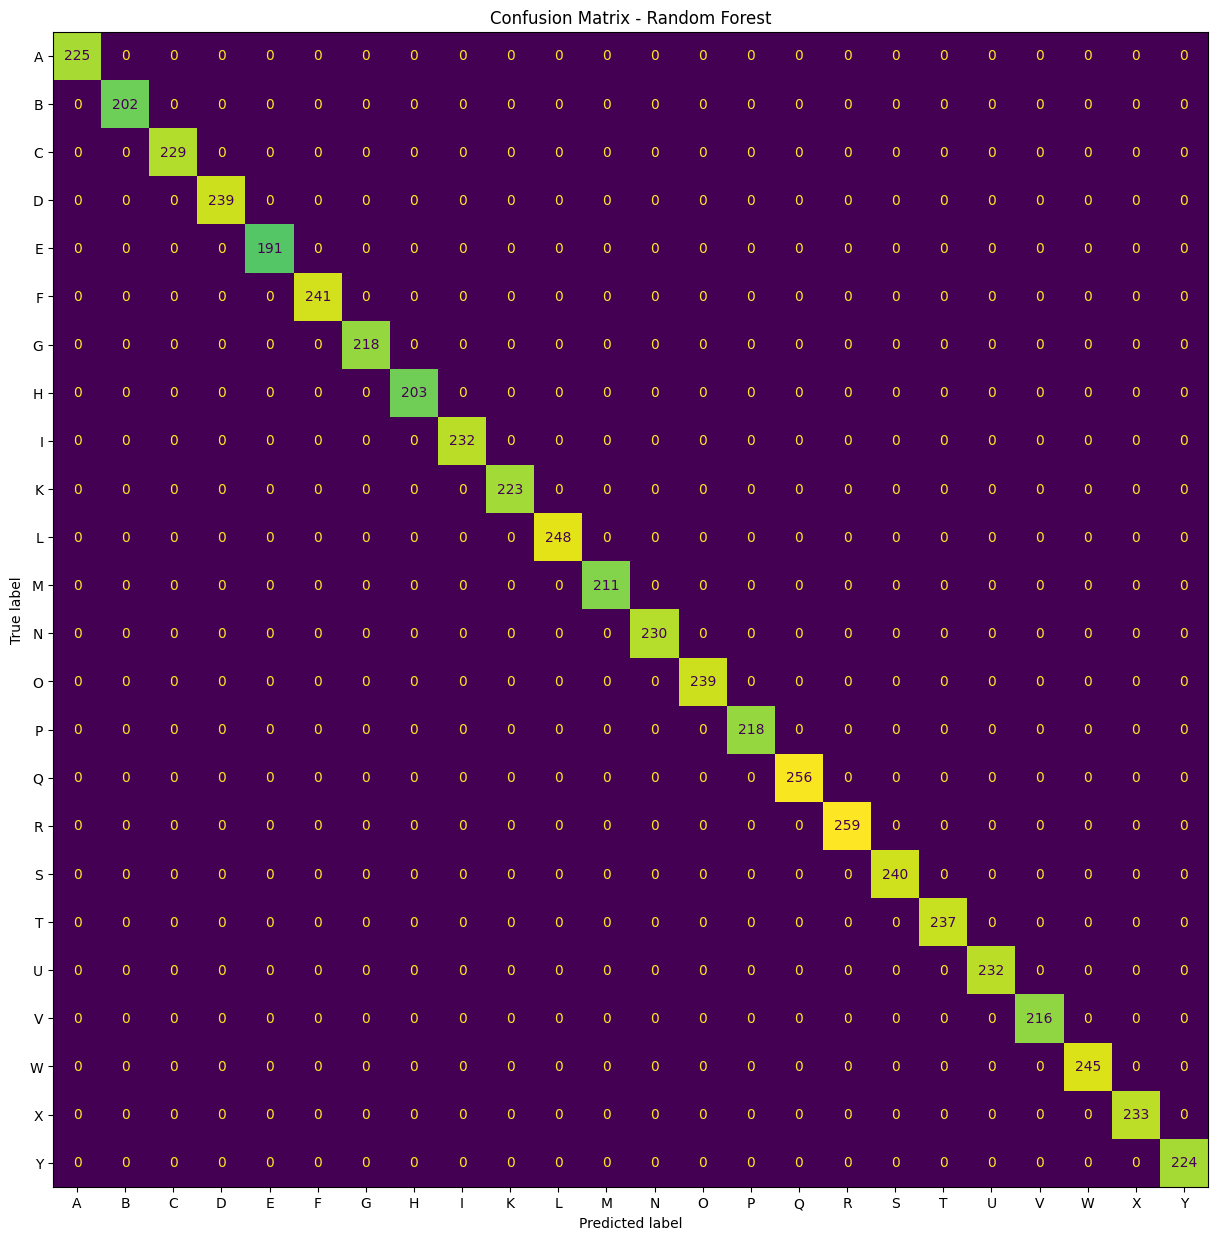

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Προβλέψεις στο validation set
y_pred_val = best_pipeline.predict(X_val)

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred_val)

# Οπτικοποίηση
fig, ax = plt.subplots(figsize=(15, 15))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=list(LABEL_TO_LETTER.values()))
disp.plot(ax=ax, colorbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.show()

## 5. Conclusions

### 5.1 Summary
This project explored 7 classification algorithms for ASL hand sign recognition:

| Model | Validation Accuracy |
|-------|-------------------|
| kNN | 1.0000 |
| SVM | 1.0000 |
| Decision Tree | 0.8931 |
| Random Forest | 0.9965 |
| AdaBoost | 0.3100 |
| FNN | 1.0000 |
| CNN | 1.0000 |

### 5.2 Key Findings

1. **Overfitting on validation set:** Most models achieved near-perfect 
validation accuracy due to the augmented nature of the dataset.

2. **AdaBoost limitations:** AdaBoost performed poorly (≈29% validation, 
not tested) due to its reliance on weak base classifiers (decision stumps) 
which are insufficient for a complex 24-class image classification problem.

3. **CNN potential:** Although CNNs achieved perfect validation accuracy, 
they could not be selected as the final model due to scikit-learn constraints. 
In a real-world scenario, CNNs would likely outperform all other models on 
truly unseen data.

### 5.3 Hidden Phrase Challenge
The final Random Forest Pipeline was used to implement the `predict_letters` 
function, which takes a set of images and returns the predicted phrase:

- **Input:** NumPy array of raw grayscale images (0-255)
- **Output:** String of predicted letters

The Pipeline automatically applies normalization before prediction, ensuring 
correct and consistent results regardless of the input scale.